In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
from pathlib import Path

In [13]:
load_dotenv()
SERVER = os.environ.get("DB_SERVER")
DATABASE = os.environ.get("DB_NAME")
DRIVER = os.environ.get("DB_DRIVER")
PATH_STRING = os.environ.get("FILE_PATH")

QUERIES_FOLDER = Path(PATH_STRING) / "queries" 
SQL_FILE_PATH = QUERIES_FOLDER / "delivery_time.sql"

print(SQL_FILE_PATH)

C:\Users\Viggo\Py\Learning Project\da_projects\Ecom-Project\queries\delivery_time.sql


In [14]:
with open(SQL_FILE_PATH, 'r') as file: 
    sql_query = file.read()

engine = create_engine(f"mssql+pyodbc://{SERVER}/{DATABASE}?driver={DRIVER}")

df = pd.read_sql_query(sql_query, con=engine)


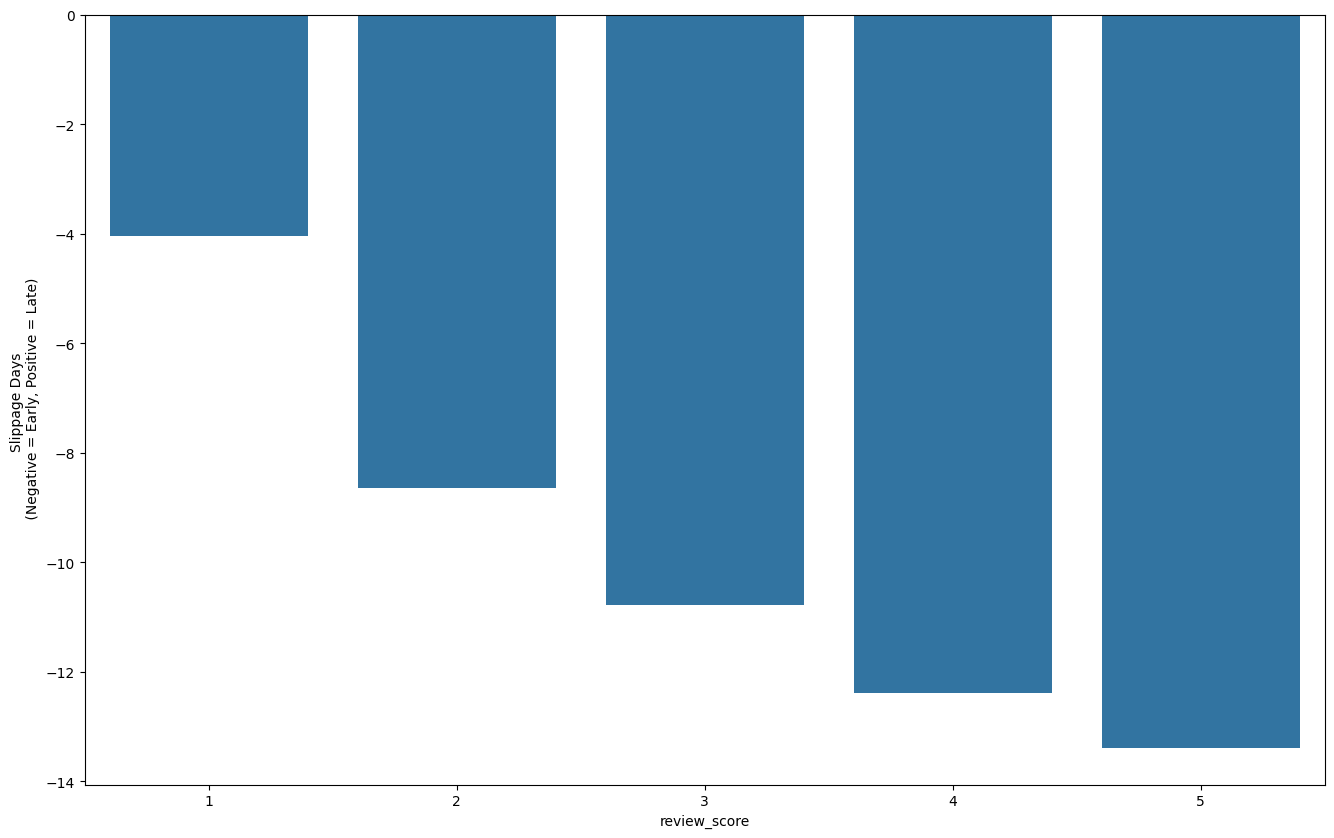

In [38]:
# Review Scores vs. Delivery Speed (scatter plot)
# convert dates columns to date time
columns_to_datetime = ["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]
df[columns_to_datetime] = df[columns_to_datetime].apply(pd.to_datetime, errors = "coerce")

# get the duration of delivery in days
df["delivery_duration"]  = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.days
df["deliver_slippage_days"] = (df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]).dt.days

# make scatter plot
plt.figure(figsize=(16,10))
sns.barplot(df, x="review_score", y="deliver_slippage_days", errorbar=None)
plt.ylabel("Slippage Days \n (Negative = Early, Positive = Late)")
plt.show()